# Linerar Regression

Linear Regression is a supervised learning algorithm used to predict a continuous numerical value. We assume and fit a one-degree single or multiple feature polynomial, hence the name linear.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model

## Single feature

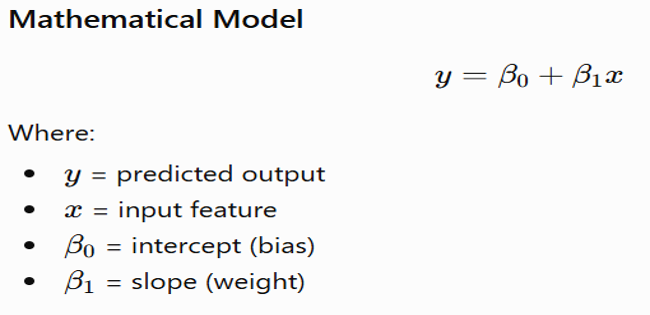!

## using sklearn

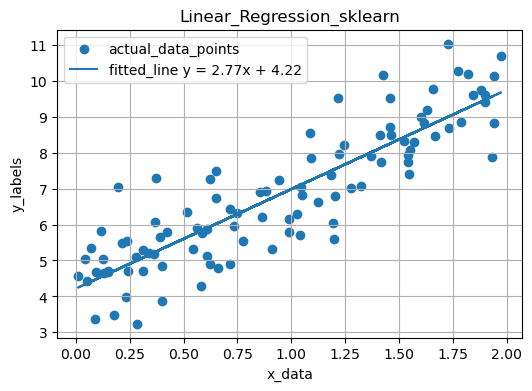

In [2]:
np.random.seed(42)
x = 2 * np.random.rand(100)
y = 4 + 3 * x + np.random.randn(100)
x_train = x.reshape(-1,1)
reg = linear_model.LinearRegression()
reg.fit(x_train,y)
coff = reg.coef_[0]
inter = reg.intercept_
def get_predictions(coff, inter, x):
    return x*coff + inter
y_fit = get_predictions(coff, inter, x)
plt.figure(figsize = (6,4))
plt.grid()
plt.title('Linear_Regression_sklearn')
plt.xlabel('x_data')
plt.ylabel('y_labels')
plt.scatter(x,y, label= 'actual_data_points')
plt.plot(x,y_fit, label = f'fitted_line y = {coff:.2f}x + {inter:.2f}')
plt.legend()
plt.show()

## from scratch using gradiant descesnt

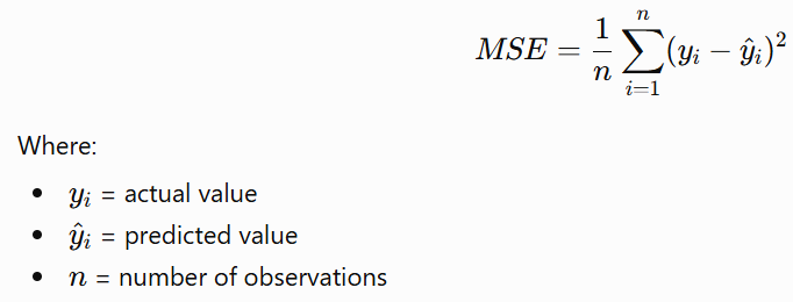

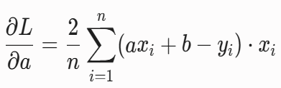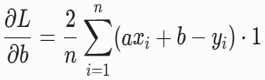
The code below implements the iterative gradient descent, updating the weights and bias as: a = a – eta*a, where eta is the learning rate.

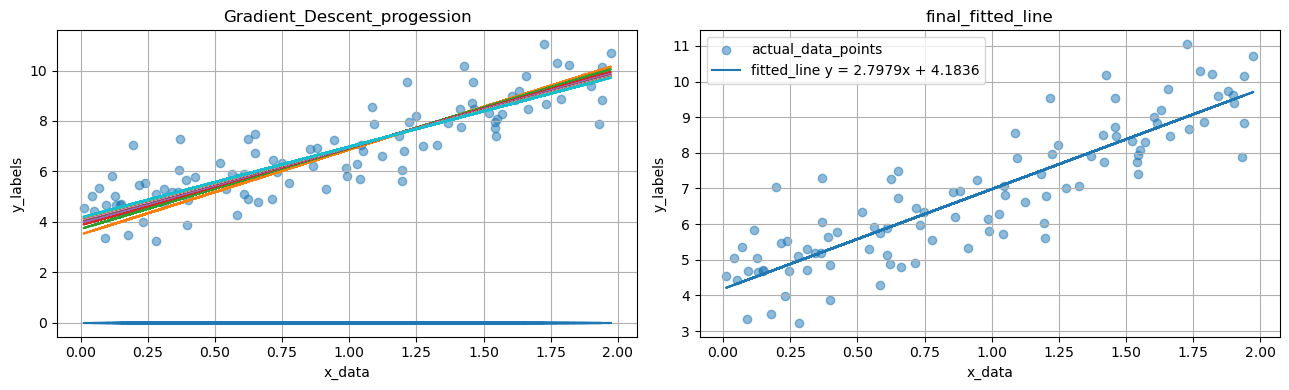

In [3]:
np.random.seed(42)
x = 2 * np.random.rand(100)
y = 4 + 3*x + np.random.randn(100)
n = len(x)
plt.figure(figsize =(13,4))
plt.subplot(1,2,1)
plt.title('Gradient_Descent_progession')
plt.xlabel('x_data')
plt.ylabel('y_labels')
plt.grid()
plt.scatter(x,y, alpha = 0.5)
def get_constants(x,y,eta):
    c = 0.0
    slope = 0.0
    itr_max = 100
    plt.subplot(1,2,2)
    for itr in range(itr_max):
        y_pred = c + slope*x
        if itr%10 == 0:
            plt.subplot(1,2,1)
            plt.plot(x,y_pred)   
        residual = y - y_pred
        d_inter = (-2/n)*np.sum(residual)
        d_slope = (-2/n)*np.sum(x*residual)
        c = c - eta*d_inter
        slope = slope - eta*d_slope
    return slope, c

def get_predictions(slope, c, x):
    return x*slope + c
slope, c = get_constants(x,y,0.1)
y_pred = get_predictions(slope, c, x)
plt.subplot(1,2,2)
plt.grid()
plt.xlabel('x_data')
plt.ylabel('y_labels')
plt.scatter(x,y, label= 'actual_data_points', alpha = 0.5)
plt.plot(x,y_pred, label = f'fitted_line y = {slope:.4f}x + {c:.4f}')
plt.title('final_fitted_line')
plt.legend()
plt.tight_layout()
plt.show()

## Multiple Features

When the target variable depends on more than one feature, Multiple Linear Regression is used. The multivariate extension generalises the gradient descent framework to a regression plane. 
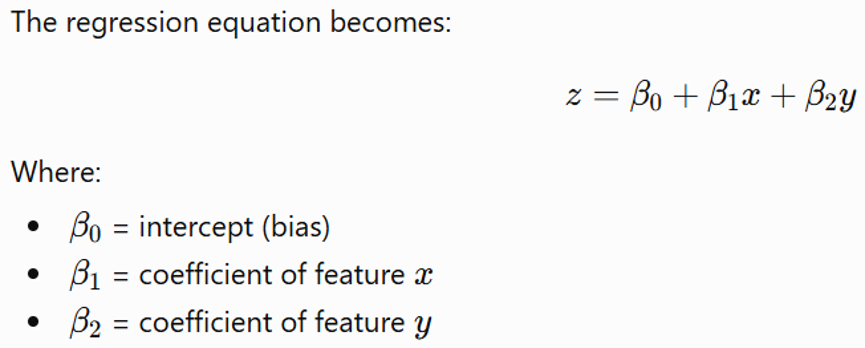
## corresponding partial derivatives
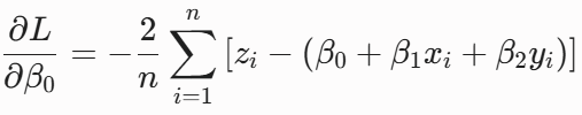
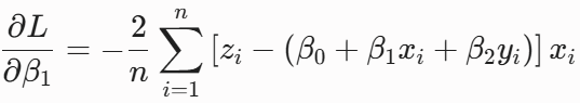
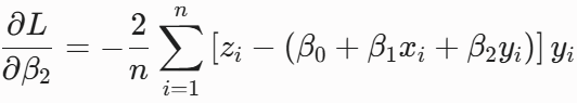

coefficients: a = 2.6583, b = 4.7193, c = 1.9106


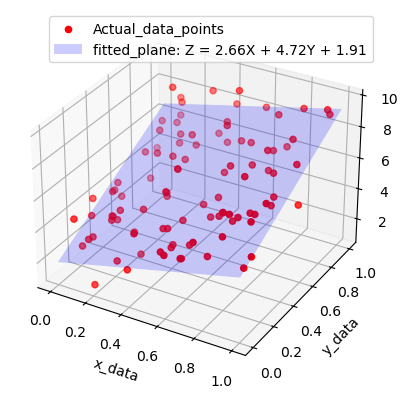

In [4]:
np.random.seed(42)
x = np.random.rand(100)
y = np.random.rand(100)
z = 3*x + 4*y + 2 + np.random.randn(100)

a,b,c = 0.0,0.0,0.0
eta = 0.03
itr_max = 10000
z_fit = a*x + b*y + c
for itr in range(itr_max):
    z_fit = a*x + b*y + c
    residual = z - z_fit
    d_a = (-2/100)*np.sum(x*residual)
    d_b = (-2/100)*np.sum(y*residual)
    d_c = (-2/100)*np.sum(residual)
    a = a - eta*d_a
    b = b - eta*d_b
    c = c - eta*d_c
print(f'coefficients: a = {a:.4f}, b = {b:.4f}, c = {c:.4f}')
ax = plt.axes(projection='3d')
ax.scatter(x,y,z, color = 'red', label = 'Actual_data_points')
x_surf = np.linspace(0, 1, 20)
y_surf = np.linspace(0, 1, 20)
X, Y = np.meshgrid(x_surf, y_surf)
Z_fit = a*X + b*Y + c

ax.plot_surface(X,Y,Z_fit, color = 'blue',  alpha= 0.2, label = f'fitted_plane: Z = {a:.2f}X + {b:.2f}Y + {c:.2f}')
ax.set_xlabel('x_data')
ax.set_ylabel('y_data')
ax.set_zlabel('z_label')
plt.legend()
plt.show()

## Polynomial regression

Polynomial regression extends the linear model by incorporating higher-order terms of the input feature
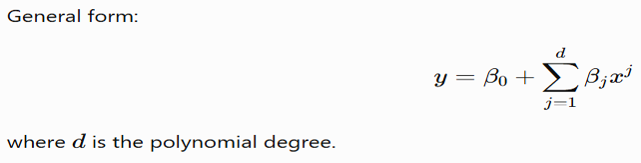

example using quadratic model
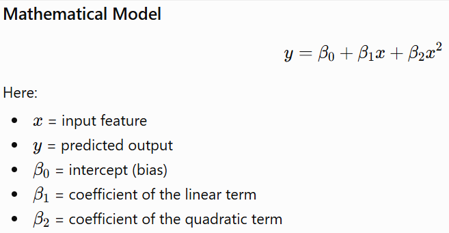
## the deivaives

-1.7805638095762335


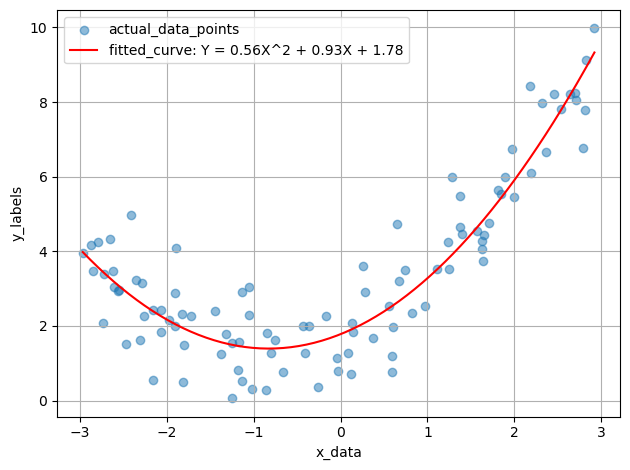

In [5]:
from sklearn.metrics import r2_score
np.random.seed(42)
x = 6 * np.random.rand(100) - 3
y = 0.5 * x**2 + x + 2 + np.random.randn(100)
def get_constants(x,y,eta):
    itr_max = 100000
    a,b,c = 0.0, 0.0, 0.0
    for itr in range(itr_max):
        y_fit = a*(x**2) + b*x + c
        residual = y - y_fit
        d_a = (-2/100)*np.sum((x**2)*(residual))
        d_b = (-2/100)*np.sum(x*(residual))
        d_c = (-2/100)*np.sum(residual)
        a = a - eta*d_a
        b = b - eta*d_b
        c = c - eta*d_c
    return a,b,c
def get_predictions(a,b,c,x):
    return a*(x**2) + b*x + c

a,b,c = get_constants(x,y,0.0005)    
x_smooth = np.linspace(x.min(), x.max(), 200)
y_smooth = a*(x_smooth**2) + b*x_smooth + c
plt.grid()
plt.xlabel('x_data')
plt.ylabel('y_labels')
plt.scatter(x,y, label= 'actual_data_points', alpha = 0.5)
plt.plot(x_smooth,y_smooth, color='red', label=f'fitted_curve: Y = {a:.2f}X^2 + {b:.2f}X + {c:.2f}')
plt.legend()
plt.tight_layout()
print(r2_score(y,y_fit))
plt.show()